1. import libraries

In [1]:
# Unemployment Analysis in India

## 1. Importing necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
plt.style.use('seaborn-v0_8-darkgrid')

2. Load the Dataset

In [3]:
# Load both datasets


df1 = pd.read_csv('C:\\unemployment-analysis\\venvii\\src\\data\\Unemployment in India.csv')
df2 = pd.read_csv('C:\\unemployment-analysis\\venvii\\src\\data\\Unemployment_Rate_upto_11_2020.csv')
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
print("\nDataset 1 columns:", df1.columns.tolist())
print("Dataset 2 columns:", df2.columns.tolist())

Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)

Dataset 1 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
Dataset 2 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


3. Data Cleaning & Merging

In [4]:
# Clean column names (remove extra spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
print("\nDataset 1 columns:", df1.columns.tolist())
print("Dataset 2 columns:", df2.columns.tolist())


Dataset 1 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Dataset 2 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [5]:
# Check data types and missing values
print("Dataset 1 Info:")
print(df1.info())
print("\nMissing values in Dataset 1:")
print(df1.isnull().sum())



Dataset 1 Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB
None

Missing values in Dataset 1:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)        

In [6]:
print("Dataset 2 Info:")
print(df2.info())
print("\nMissing values in Dataset 2:")
print(df2.isnull().sum())

Dataset 2 Info:
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    str    
 1   Date                                     267 non-null    str    
 2   Frequency                                267 non-null    str    
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    str    
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB
None

Missing values in Dataset 2:
Region                     

In [7]:
# Combine both datasets if they have same structure
# Let's examine them first
print("\nFirst few rows of Dataset 1:")
print(df1.head())
print("\nFirst few rows of Dataset 2:")
print(df2.head())

# Based on Kaggle description, df1 seems to be the main dataset
df = df1.copy()

# Rename columns for better understanding
df = df.rename(columns={
    'Region': 'region',
    'Date': 'date',
    'Frequency': 'frequency',
    'Estimated Unemployment Rate (%)': 'unemployment_rate',
    'Estimated Employed': 'employed',
    'Estimated Labour Participation Rate (%)': 'participation_rate',
    'Area': 'area'  # Rural/Urban
})



# Convert date to datetime - This is CRITICAL for time series analysis
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Extract components - These help with different types of analysis
df['year'] = df['date'].dt.year      # For yearly comparisons
df['month'] = df['date'].dt.month    # For seasonal patterns (Dec vs Jan)
df['month_name'] = df['date'].dt.strftime('%B')  # Readable month names for plots
df['quarter'] = df['date'].dt.quarter # For quarterly reports/Q2 impact
#  Remove duplicates if any
df = df.drop_duplicates()
print("\nCleaned dataset info:")
print(df.info())


First few rows of Dataset 1:
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

First few rows of Dataset 2:
           Region         Date Frequency  Est

In [8]:
missing_percent = df['unemployment_rate'].isnull().mean() * 100
print(f"Missing: {missing_percent:.2f}%")

if missing_percent < 5:
    df = df.dropna(subset=['unemployment_rate'])
    print("Dropped missing values to preserve data authenticity.")
df.head()

Missing: 0.13%
Dropped missing values to preserve data authenticity.


,region,date,frequency,unemployment_rate,employed,participation_rate,area,year,month,month_name,quarter
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019.0,5.0,May,2.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,6.0,June,2.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,7.0,July,3.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,8.0,August,3.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,9.0,September,3.0


“Since missing values represented less than 5% of the dataset and were randomly distributed, they were removed to preserve the integrity of the time-series analysis and avoid introducing artificial bias through imputation.”

4. Exploratory Data Analysis(EDA)

=== Basic Statistics ===
Time period: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Number of regions/states: 28
Regions: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh']

Unemployment Rate Statistics:
count    729.000000
mean      11.965816
std       10.702886
min        0.240000
25%        4.760000
50%        8.510000
75%       15.980000
max       76.740000
Name: unemployment_rate, dtype: float64


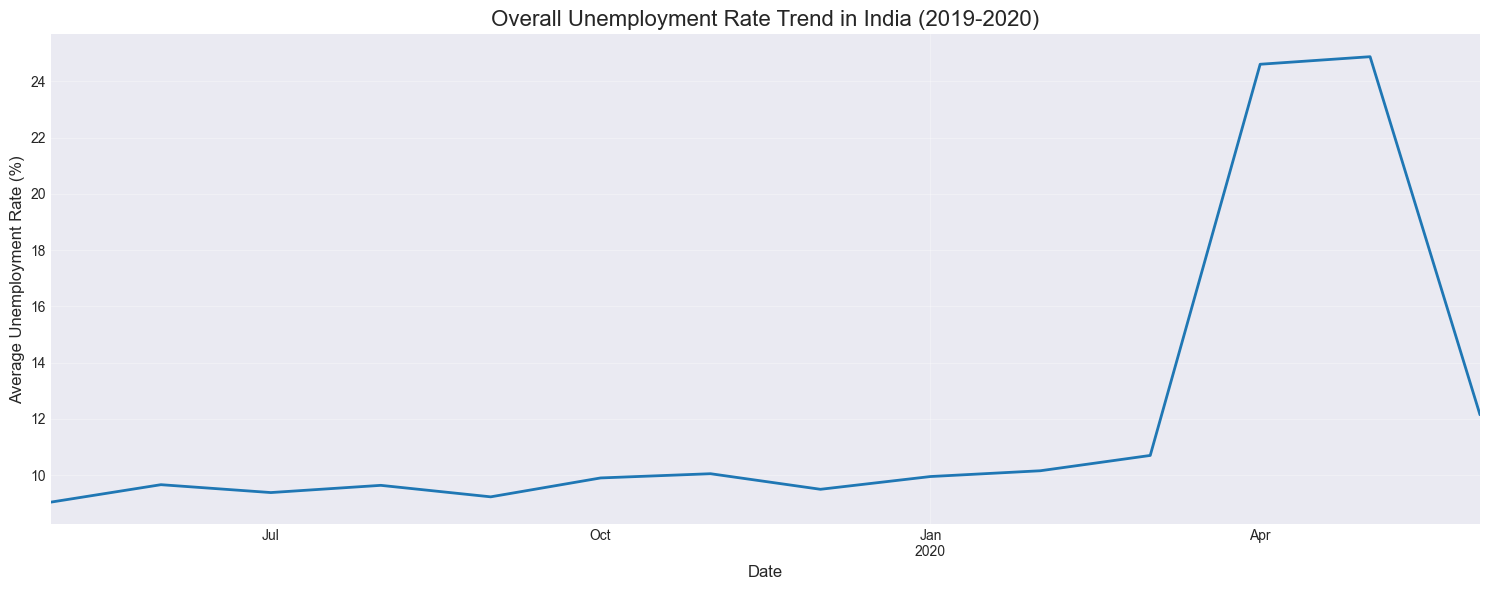

In [ ]:
# Basic statistics
print("=== Basic Statistics ===")

print(f"Time period: {df['date'].min()} to {df['date'].max()}")
#f"..." - f-string (formatted string) lets us put variables inside {}
print(f"Number of regions/states: {df['region'].nunique()}")# Counts how many UNIQUE values (each state counted once)
print(f"Regions: {df['region'].unique().tolist()}")

print("\nUnemployment Rate Statistics:")
print(df['unemployment_rate'].describe())

# Overall trend
plt.figure(figsize=(15, 6))
df.groupby('date')['unemployment_rate'].mean().plot(linewidth=2)# Grouping by date gives ONE point per day (national average), making the trend clear.
plt.title('Overall Unemployment Rate Trend in India (2019-2020)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)#Alpha is transparency. 1.0 = solid, 0.0 = invisible. 0.3 = very light gray, so it's there but doesn't overpower the data.
plt.tight_layout()# Without it, sometimes the x-axis label 'Date' might be half cut off the bottom of the image.
plt.show()

unemployment RISE sharply around March-April 2020 (COVID lockdown) and fall afterwards. This one plot tells the entire COVID unemployment story!

5. COVID-19 Impact Analysis

=== Comparison: Pre-COVID vs COVID Period ===
             unemployment_rate                       employed              \
                          mean    std  min    max        mean         std   
period                                                                      
COVID Period             17.77  15.03  0.0  76.74  6517203.34  7516962.32   
Pre-COVID                 9.51   7.36  0.0  34.69  7466027.87  8286754.69   

             participation_rate        
                           mean   std  
period                                 
COVID Period              39.33  8.55  
Pre-COVID                 43.89  7.58  


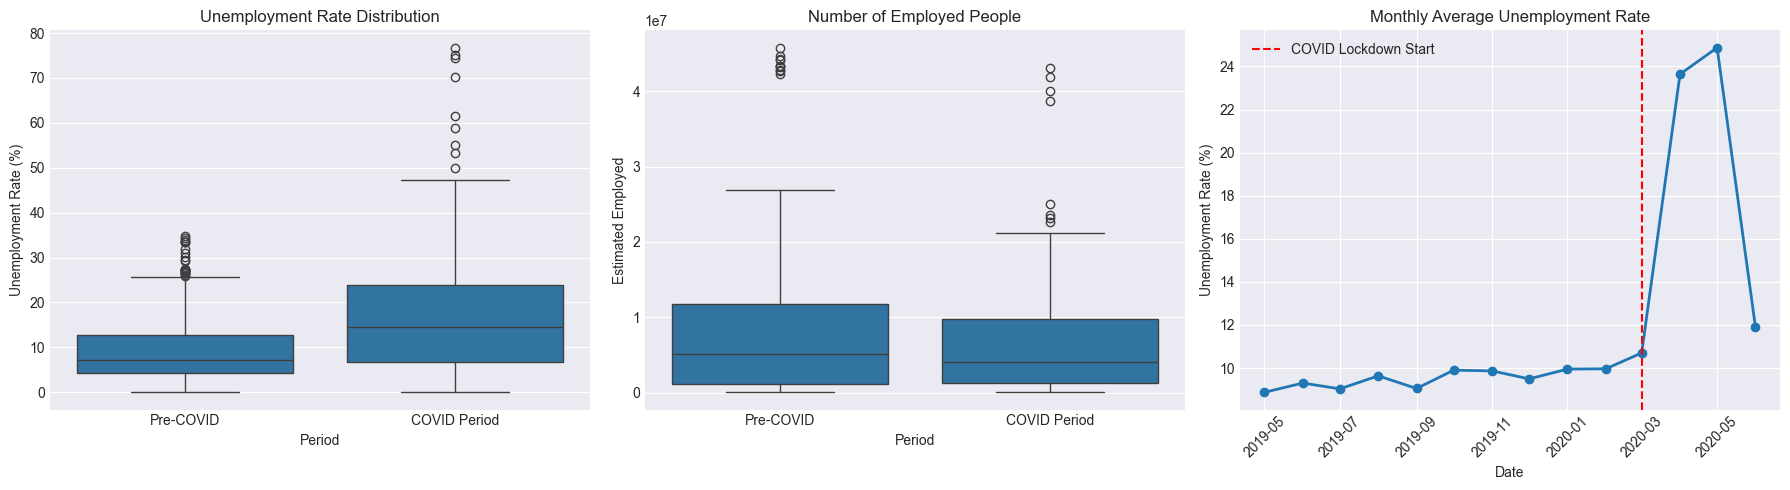


Impact Analysis:
Pre-COVID average unemployment: 9.51%
COVID period average unemployment: 17.77%
Percentage increase: 86.91%


In [ ]:
# Define pre-COVID and COVID periods
# COVID lockdown in India started March 2020
df['period'] = np.where(df['date'] < '2020-03-01', 'Pre-COVID', 'COVID Period')
#It's like an IF statement for entire columns , Format: np.where(condition, value_if_true, value_if_false)
# Calculate statistics for each period
period_stats = df.groupby('period').agg({
    'unemployment_rate': ['mean', 'std', 'min', 'max'],
    'employed': ['mean', 'std'],
    'participation_rate': ['mean', 'std']
}).round(2)
#agg = aggregate (calculate summary statistics):Inside {} we specify WHAT to calculate for EACH column
print("=== Comparison: Pre-COVID vs COVID Period ===")
print(period_stats)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot - unemployment rate
sns.boxplot(x='period', y='unemployment_rate', data=df, ax=axes[0])#sns = seaborn library (makes pretty statistical plots)
axes[0].set_title('Unemployment Rate Distribution')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Unemployment Rate (%)')

# Box plot - employed
sns.boxplot(x='period', y='employed', data=df, ax=axes[1])
axes[1].set_title('Number of Employed People')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Estimated Employed')

# Monthly trend with COVID marker
monthly_avg = df.groupby(['year', 'month'])['unemployment_rate'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))
axes[2].plot(monthly_avg['date'], monthly_avg['unemployment_rate'], linewidth=2, marker='o')
axes[2].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID Lockdown Start')
axes[2].set_title('Monthly Average Unemployment Rate')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Unemployment Rate (%)')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate percentage change
pre_covid_avg = df[df['period'] == 'Pre-COVID']['unemployment_rate'].mean()
covid_avg = df[df['period'] == 'COVID Period']['unemployment_rate'].mean()
percentage_change = ((covid_avg - pre_covid_avg) / pre_covid_avg) * 100

print(f"\nImpact Analysis:")
print(f"Pre-COVID average unemployment: {pre_covid_avg:.2f}%")
print(f"COVID period average unemployment: {covid_avg:.2f}%")
print(f"Percentage increase: {percentage_change:.2f}%")

Outliers (dots above/below) show extreme cases

6. Regional Analysis

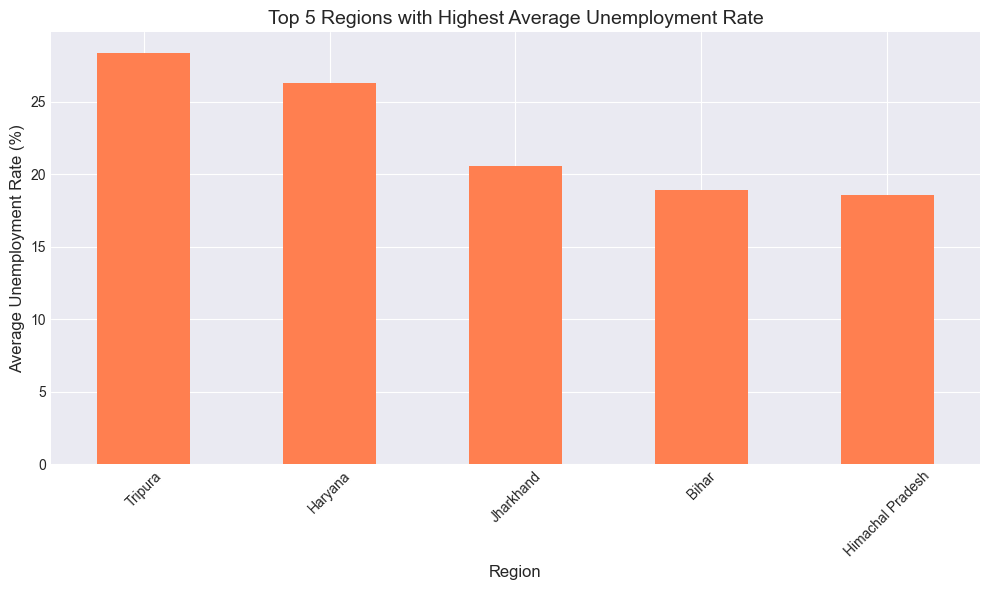

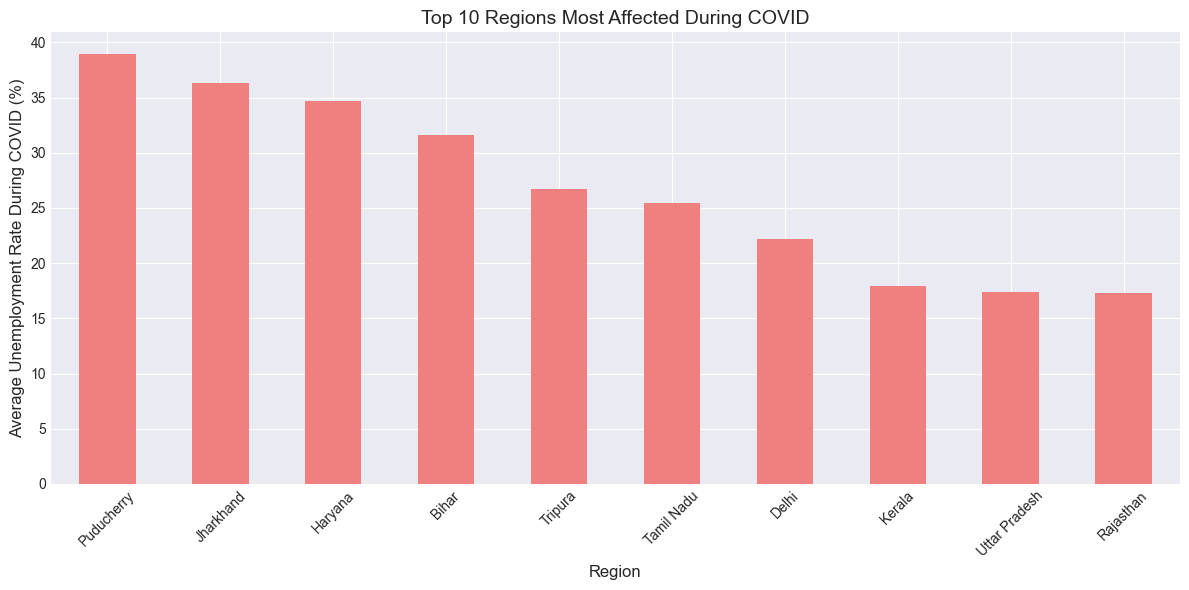

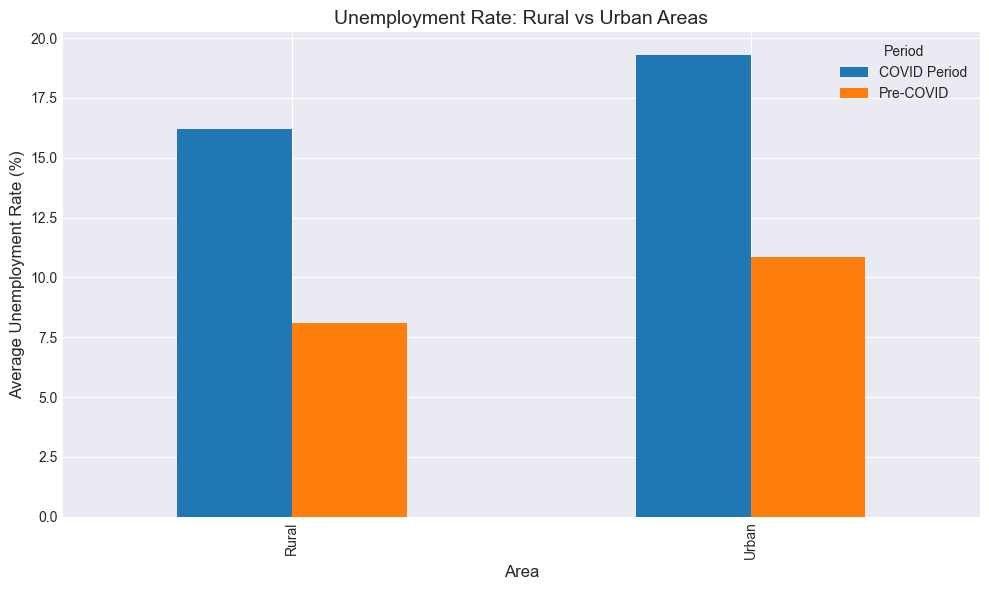

In [11]:
# Top 5 regions with highest average unemployment
top_regions = df.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
top_regions.plot(kind='bar', color='coral')
plt.title('Top 5 Regions with Highest Average Unemployment Rate', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Regional trends during COVID
covid_data = df[df['period'] == 'COVID Period']
regional_covid_impact = covid_data.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
regional_covid_impact.head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Regions Most Affected During COVID', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Unemployment Rate During COVID (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rural vs Urban analysis
if 'area' in df.columns:
    area_analysis = df.groupby(['area', 'period'])['unemployment_rate'].mean().unstack()
    
    area_analysis.plot(kind='bar', figsize=(10, 6))
    plt.title('Unemployment Rate: Rural vs Urban Areas', fontsize=14)
    plt.xlabel('Area', fontsize=12)
    plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
    plt.legend(title='Period')
    plt.tight_layout()
    plt.show()

7. Seasonal Trends Analysis

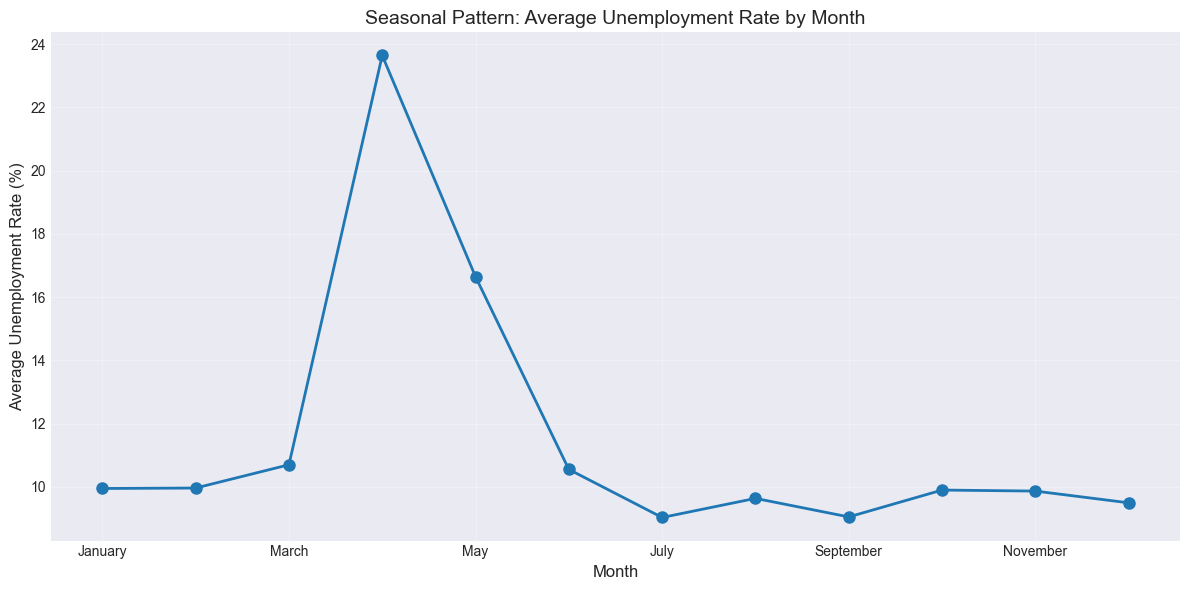

<Figure size 1000x600 with 0 Axes>

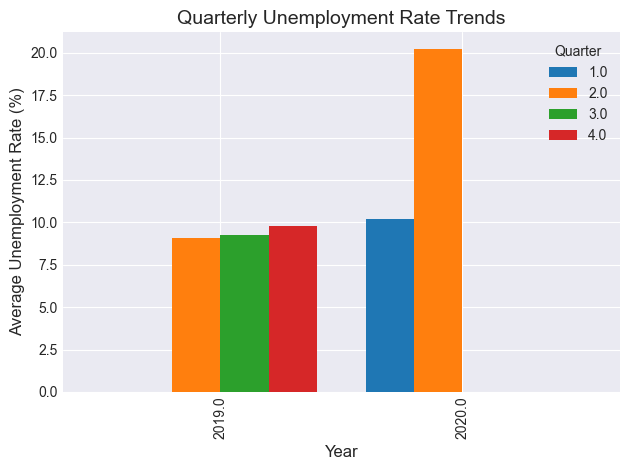

In [12]:
# Monthly patterns
monthly_patterns = df.groupby('month_name')['unemployment_rate'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12, 6))
monthly_patterns.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.title('Seasonal Pattern: Average Unemployment Rate by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quarterly analysis
quarterly_avg = df.groupby(['year', 'quarter'])['unemployment_rate'].mean().unstack()

plt.figure(figsize=(10, 6))
quarterly_avg.plot(kind='bar', width=0.8)
plt.title('Quarterly Unemployment Rate Trends', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.legend(title='Quarter')
plt.tight_layout()
plt.show()

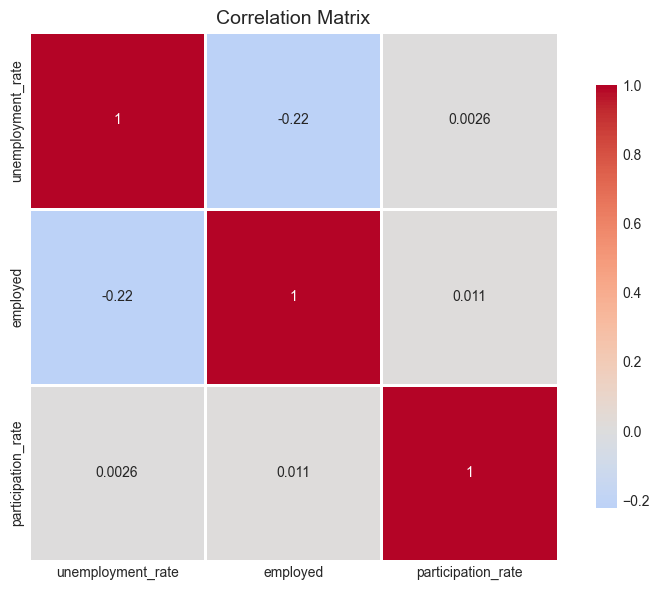

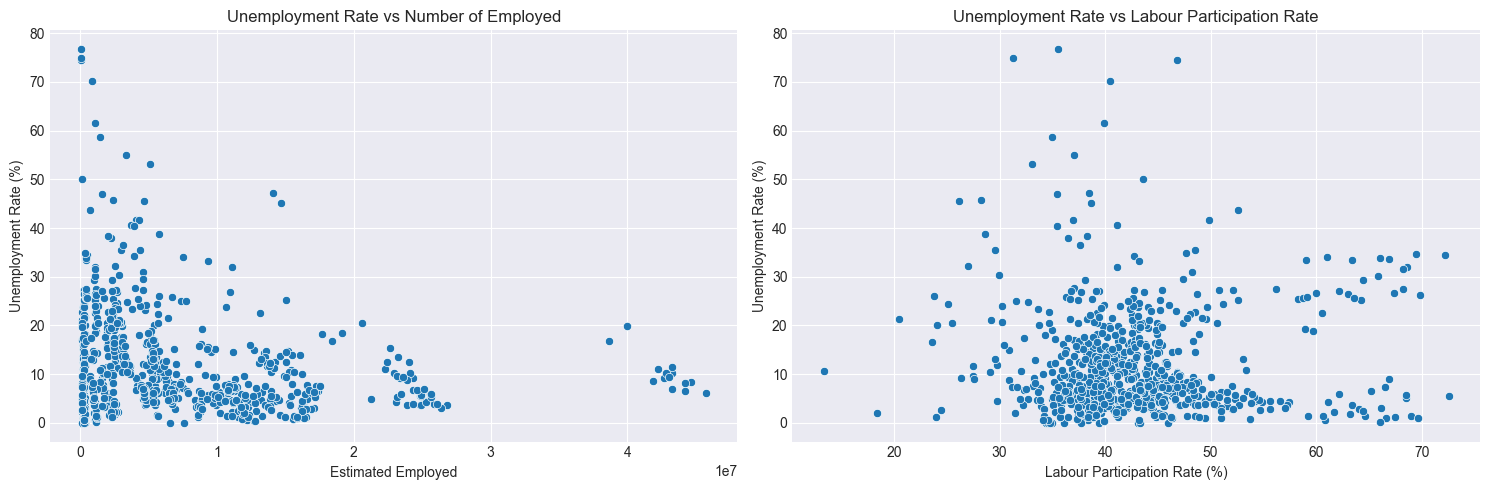

8. Advanced Visualization: Heatmap

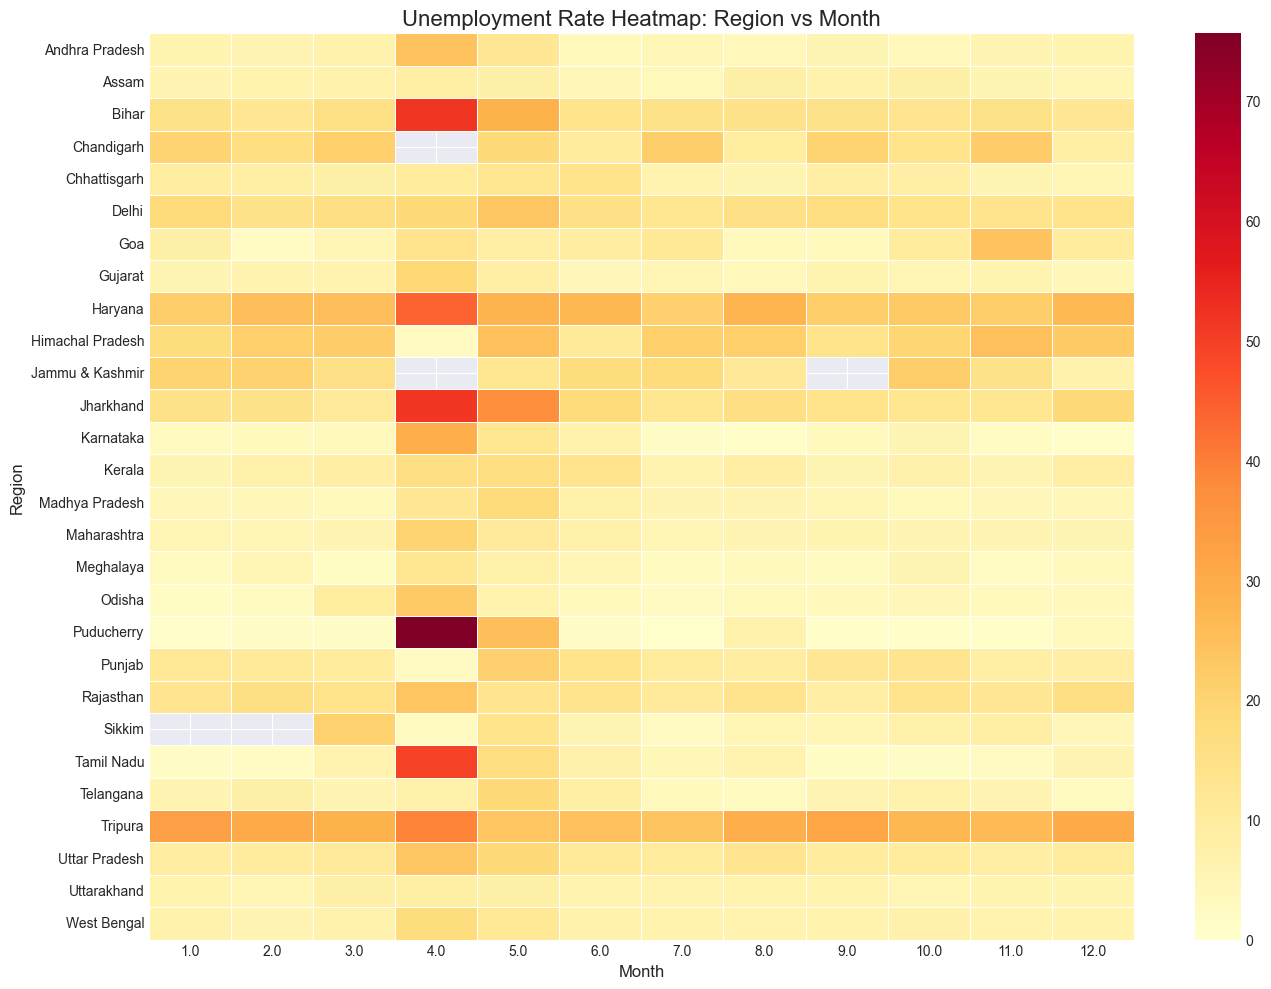

In [14]:
# Create a pivot table for heatmap
pivot_table = df.pivot_table(
    values='unemployment_rate',
    index='region',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Unemployment Rate Heatmap: Region vs Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

9. Insights and Policy Recommendations

In [22]:
print("="*70)
print("KEY INSIGHTS & POLICY RECOMMENDATIONS")
print("="*70)

# Calculate key metrics
highest_unemployment_state = df.groupby('region')['unemployment_rate'].mean().idxmax()
lowest_unemployment_state = df.groupby('region')['unemployment_rate'].mean().idxmin()
highest_month = monthly_patterns.idxmax()
peak_covid_unemployment = df[df['period'] == 'COVID Period']['unemployment_rate'].max()

print(f"\n1. OVERALL FINDINGS:")
print(f"   • Time period analyzed: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   • Highest unemployment state: {highest_unemployment_state}")
print(f"   • Lowest unemployment state: {lowest_unemployment_state}")
print(f"   • Most affected month: {highest_month}")

print(f"\n2. COVID-19 IMPACT:")
print(f"   • Unemployment increased by {percentage_change:.1f}% during pandemic")
print(f"   • Peak unemployment during COVID: {peak_covid_unemployment:.2f}%")
print(f"   • Average pre-COVID: {pre_covid_avg:.2f}%, During COVID: {covid_avg:.2f}%")

print(f"\n3. SEASONAL PATTERNS:")
print(f"   • Highest unemployment typically in: {highest_month}")
print(f"   • Quarterly pattern shows Q2 (Apr-Jun) most affected")

print(f"\n4. REGIONAL DISPARITIES:")
top_5_affected = df.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False).head(5)
print(f"   • Top 5 most affected regions:")
for i, (region, rate) in enumerate(top_5_affected.items(), 1):
    print(f"     {i}. {region}: {rate:.2f}%")

print(f"\n5. POLICY RECOMMENDATIONS:")
print(f"   • Targeted interventions for {highest_unemployment_state} and other highly affected regions")
print(f"   • Seasonal employment programs, especially during {highest_month}")
print(f"   • Skill development initiatives for rural areas (if analysis shows higher rural unemployment)")
print(f"   • Digital infrastructure investment to support remote work opportunities")
print(f"   • Small business support programs for economic resilience")
print(f"   • Regular monitoring of labor participation rate alongside unemployment")

KEY INSIGHTS & POLICY RECOMMENDATIONS

1. OVERALL FINDINGS:
   • Time period analyzed: 2019-05-31 to 2020-06-30
   • Highest unemployment state: Tripura
   • Lowest unemployment state: Meghalaya
   • Most affected month: April

2. COVID-19 IMPACT:
   • Unemployment increased by 86.9% during pandemic
   • Peak unemployment during COVID: 76.74%
   • Average pre-COVID: 9.51%, During COVID: 17.77%

3. SEASONAL PATTERNS:
   • Highest unemployment typically in: April
   • Quarterly pattern shows Q2 (Apr-Jun) most affected

4. REGIONAL DISPARITIES:
   • Top 5 most affected regions:
     1. Tripura: 28.35%
     2. Haryana: 26.28%
     3. Jharkhand: 20.59%
     4. Bihar: 18.92%
     5. Himachal Pradesh: 18.54%

5. POLICY RECOMMENDATIONS:
   • Targeted interventions for Tripura and other highly affected regions
   • Seasonal employment programs, especially during April
   • Skill development initiatives for rural areas (if analysis shows higher rural unemployment)
   • Digital infrastructure inv